<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> Mid-Term Assignment - CSV to Data Warehouse </b></h3>

<div style="background-color:#f8f9fa; padding:15px; border-radius:10px; border:1px solid #FF8DA1;">
<h3><b> Table of Contents</b></h3>

1. [Introduction and Selection of Dataset](#introduction)
2. [Libraries and Environment Setup](#libraries)
3. [Data Loading and Merging](#load)
4. [Data Cleaning](#clean)
5. [Star Schema: Dimensions Construction](#dimensions)
5. [Fact Table Construction](#fact-table)
6. [SQL Database Export](#sql)
7. [Exploratory Data Analysis (SQL Queries)](#analysis)
8. [Visual Insights (Seaborn)](#visuals)
</div>

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="introduction"></a> Introduction and Selection of Dataset </b></h3>

### **Introduction & Project Goals**

The primary goal of this project is to build a **Star Schema Data Warehouse** by trasnforming a raw CSV dataset using **Python and SQLite**. This work focuses on the entire ETL cycle: extracting raw data, transforming formats, and loading them into a **centralized analytical database** for the movie industry.


### **Dataset Selection**

After evaluating all the three dataset options, the **TMDB 5000 Movies Dataset** was selected out of the list for the following reasons:

- **Meaningful Insights**: The variety of attributes allows for creative and especially useful business insights, such as comparing success across different genres or directors and if the release date is a key factor in a movie's sucess, helping determine the best timing for future releases.

- **Dataset Structure**: The way the data is organized made it a really good option to build a solid Star Schema with a clear Fact table and meaningful Dimensions.

- **Personal Interest in the Theme**: Working with movie data is much more engaging and intuitive than medical records or music technicalities, making the analysis process more interesting for our group.

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="libraries"></a> Libraries and Environment Setup </b></h3>

In [1]:
import pandas as pd
import numpy as np
import ast #allow us to explode information in a json format
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

#display configuration to avoid scientific notation (e+09)
pd.options.display.float_format = '{:.2f}'.format

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="load"></a> Data Loading and Merging </b></h3>

The TMDB 5000 dataset is provided as two separate CSV files. 
One containing **general movie data**, such as budget, revenue, genres (df_1) and another containing **specific credits** , like cast and crew (df_2). The first step was to load both files and **merge them into a single DataFrame**, we performed this merge using the **unique movie ID** present in both files. 


This was a crucial step to ensure that, later on, the metrics could be correctly linked to each other. 

In [2]:
#loading datasets
df_1 = pd.read_csv('tmdb_5000_movies.csv')
df_2 = pd.read_csv('tmdb_5000_credits.csv')


#merging based on the unique ID
#the 'id' in df_1 and 'movie_id' in df_2 are the same entity
df_combined = pd.merge(df_1, df_2, left_on = 'id', right_on = 'movie_id')

#cleaning up redundant information after merging
df_combined.drop(columns= ['movie_id', 'title_y'], inplace = True)
df_combined.rename(columns= {'title_x' : 'title'}, inplace= True)

In [3]:
#quick exploration
print(f"Dataset Dimensions: {df_combined.shape}")

Dataset Dimensions: (4803, 22)


<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="clean"></a> Data Cleaning ( Missing Values, Duplicate Records, Change Datatypes) </b></h3>

#### **Handling Missing Values**

Having missing values in our fact table and/or dimensions can be a large problem because it directly affects the accuracy of some business metrics and the reliability of our SQL joins.

In [4]:
df_combined.isna().sum() #to check the missing values per columns

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                       0
crew                       0
dtype: int64

In [5]:
'''
In the case of release_date and runtime which only have 1 and 2 missing values,
respectively, we chose to drop these rows.
Since the dataset contains 4803 records, losing 3 rows (less than 0.1% of the data) 
is insignificant and ensures that the dimensions remain accurate
without having to impute or guess these values.
'''

df_combined = df_combined.dropna(subset=['release_date'])
df_combined = df_combined.dropna(subset=['runtime'])


In [6]:
#dropping columns that are not necessary for the Star Schema
#by dropping, we focus only on the attributes that drive meaningful insights

df_combined.drop(columns = ['homepage', 'tagline', 'overview', 'keywords', 'status'], inplace = True)

#### **Handling Duplicate Records**

In [7]:
#checking for duplicate records based on movie id
duplicate_count = df_combined.duplicated(subset=['id']).sum()
print(f"Number of duplicate records found: {duplicate_count}")

Number of duplicate records found: 0


#### **Checking Data Types**

In [8]:
df_combined.dtypes

budget                    int64
genres                   object
id                        int64
original_language        object
original_title           object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
title                    object
vote_average            float64
vote_count                int64
cast                     object
crew                     object
dtype: object

In [9]:
#change some data types
df_combined['release_date'] = pd.to_datetime(df_combined['release_date'])
df_combined['budget'] = pd.to_numeric(df_combined['budget'], errors='coerce')
df_combined['revenue'] = pd.to_numeric(df_combined['revenue'], errors='coerce')

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="dimension" ></a>Star Schema: Dimensions Construction </b></h3>

In this stage of the project, we will separate the dataset into **five distinct Dimension tables**. 

Each dimension was carefully selected to answer **specific business questions regarding movie success**:


- **Dimension 1 - Dates**: Essential for **Time-Series analysis**. It allows us to see if movies released in specific months or quarters perform better financially.
- **Dimension 2 - Genres**: Developed by "exploding" the nested JSON strings. This allows us to attribute a single movie's success to multiple genres (e.g., Action and Comedy).
- **Dimension 3 - Language**: Used to analyze the reach of the movie and whether the original language impacts the global popularity score.
- **Dimension 4 - Cast**: Contains the actors involved in the production, enabling us to identify which "star power" correlates with higher box office revenue.
- **Dimension 5 - Crew**: I chose to filter the crew list specifically for Directors. This simplifies the model while keeping the most influential creative role for profit and ROI analysis.

### **Dimension 1 - Dates**

The Date Dimension is the centre of any time-series analysis. By extracting the year, month, and day name from the raw release date, we can identify **seasonal trends**.

In [10]:
dim1_date = pd.DataFrame({
    'movie_id': df_combined['id'],
    'release_date': df_combined['release_date'],
    'year': pd.to_datetime(df_combined['release_date']).dt.year,
    'month': pd.to_datetime(df_combined['release_date']).dt.month,
    'quarter': pd.to_datetime(df_combined['release_date']).dt.quarter,
    'day_of_week': pd.to_datetime(df_combined['release_date']).dt.day_name()
})

In [11]:
dim1_date #just to check

,movie_id,release_date,year,month,quarter,day_of_week
0,19995,2009-12-10,2009,12,4,Thursday
1,285,2007-05-19,2007,5,2,Saturday
2,206647,2015-10-26,2015,10,4,Monday
3,49026,2012-07-16,2012,7,3,Monday
4,49529,2012-03-07,2012,3,1,Wednesday
...,...,...,...,...,...,...
4798,9367,1992-09-04,1992,9,3,Friday
4799,72766,2011-12-26,2011,12,4,Monday
4800,231617,2013-10-13,2013,10,4,Sunday
4801,126186,2012-05-03,2012,5,2,Thursday


### **Dimension 2 - Genres**

Since a movie can belong to multiple categories, this dimension was created by **"exploding" the nested JSON data**. With this information, we can **compare the profitability and popularity** across different cinematic styles, such as Action, Comedy, or Documentary.

In [12]:
df_combined['genres'] = df_combined['genres'].apply(ast.literal_eval)
df_genres_exploded = df_combined[['id', 'genres']].explode('genres')
df_genres_exploded = df_genres_exploded.dropna(subset=['genres'])
df_genres_exploded 

,id,genres
0,19995,"{'id': 28, 'name': 'Action'}"
0,19995,"{'id': 12, 'name': 'Adventure'}"
0,19995,"{'id': 14, 'name': 'Fantasy'}"
0,19995,"{'id': 878, 'name': 'Science Fiction'}"
1,285,"{'id': 12, 'name': 'Adventure'}"
...,...,...
4800,231617,"{'id': 35, 'name': 'Comedy'}"
4800,231617,"{'id': 18, 'name': 'Drama'}"
4800,231617,"{'id': 10749, 'name': 'Romance'}"
4800,231617,"{'id': 10770, 'name': 'TV Movie'}"


In [13]:
dim_genres = pd.DataFrame({
    'movie_id': df_genres_exploded['id'],
    'genre_id': df_genres_exploded['genres'].apply(lambda x: x['id']),
    'genre_name': df_genres_exploded['genres'].apply(lambda x: x['name'])})
dim_genres

,movie_id,genre_id,genre_name
0,19995,28,Action
0,19995,12,Adventure
0,19995,14,Fantasy
0,19995,878,Science Fiction
1,285,12,Adventure
...,...,...,...
4800,231617,35,Comedy
4800,231617,18,Drama
4800,231617,10749,Romance
4800,231617,10770,TV Movie


### **Dimension 3 - Language**

This dimension **categorizes movies by their original language**. We can, then, for example, analyze the global reach of the dataset and see if **non-English films have a different ROI** profile compared to English-language productions.

In [ ]:
#this shows every language code the dataset has have
print(df_combined['original_language'].unique())

['en' 'ja' 'fr' 'zh' 'es' 'de' 'hi' 'ru' 'ko' 'te' 'cn' 'it' 'nl' 'ta'
 'sv' 'th' 'da' 'xx' 'hu' 'cs' 'pt' 'is' 'tr' 'nb' 'af' 'pl' 'he' 'ar'
 'vi' 'ky' 'id' 'ro' 'fa' 'no' 'sl' 'ps' 'el']


As there are 37 different languages on this dataset, we chose to only map the languages corresponding to the **most percentage**. As we can see here, the english and the french movies represents **more than 95%**. That is the reason why we decide to not map each language and chose only the top 12.

In [39]:
lang_distribution = df_combined['original_language'].value_counts(normalize=True) * 100

#show the top 12
print("Language Distribution (%)")
print(lang_distribution.head(12))

Language Distribution (%)
original_language
en   93.81
fr    1.46
es    0.67
zh    0.56
de    0.56
hi    0.40
ja    0.33
it    0.27
cn    0.25
ko    0.23
ru    0.23
pt    0.19
Name: proportion, dtype: float64


In [40]:
lang_map = {
    'en': 'English', 'ja': 'Japanese', 'fr': 'French', 'zh': 'Chinese',
    'es': 'Spanish', 'de': 'German', 'hi': 'Hindi', 'ru': 'Russian',
    'ko': 'Korean', 'cn': 'Cantonese', 'it': 'Italian', 'pt': 'Portuguese'
}

In [42]:
dim3_language = pd.DataFrame({
    'movie_id': df_combined['id'],
    'language_code': df_combined['original_language'],
    'language_name': df_combined['original_language'].map(lang_map).fillna('Other') #the languages not mapped will have 'Other' written in language_name
})
dim3_language

,movie_id,language_code,language_name
0,19995,en,English
1,285,en,English
2,206647,en,English
3,49026,en,English
4,49529,en,English
...,...,...,...
4798,9367,es,Spanish
4799,72766,en,English
4800,231617,en,English
4801,126186,en,English


### **Dimension 4 - Cast**

This fourth dimension stores the lead actors involved in each production. We can measure "Star Power" and analyze how the presence of **specific actors influences the movie’s overall popularity and revenue**. We also decided to keep the gender of each actor because it gives us curious insights.

In [43]:
df_combined['cast'] = df_combined['cast'].apply(ast.literal_eval)
df_cast_exploded = df_combined[['id', 'cast']].explode('cast')
df_cast_exploded = df_cast_exploded.dropna(subset=['cast'])
df_cast_exploded

ValueError: malformed node or string: [{'cast_id': 242, 'character': 'Jake Sully', 'credit_id': '5602a8a7c3a3685532001c9a', 'gender': 2, 'id': 65731, 'name': 'Sam Worthington', 'order': 0}, {'cast_id': 3, 'character': 'Neytiri', 'credit_id': '52fe48009251416c750ac9cb', 'gender': 1, 'id': 8691, 'name': 'Zoe Saldana', 'order': 1}, {'cast_id': 25, 'character': 'Dr. Grace Augustine', 'credit_id': '52fe48009251416c750aca39', 'gender': 1, 'id': 10205, 'name': 'Sigourney Weaver', 'order': 2}, {'cast_id': 4, 'character': 'Col. Quaritch', 'credit_id': '52fe48009251416c750ac9cf', 'gender': 2, 'id': 32747, 'name': 'Stephen Lang', 'order': 3}, {'cast_id': 5, 'character': 'Trudy Chacon', 'credit_id': '52fe48009251416c750ac9d3', 'gender': 1, 'id': 17647, 'name': 'Michelle Rodriguez', 'order': 4}, {'cast_id': 8, 'character': 'Selfridge', 'credit_id': '52fe48009251416c750ac9e1', 'gender': 2, 'id': 1771, 'name': 'Giovanni Ribisi', 'order': 5}, {'cast_id': 7, 'character': 'Norm Spellman', 'credit_id': '

In [44]:
gender_map = {0: 'Unknown', 1: 'Female', 2: 'Male'}

In [45]:
dim4_cast = pd.DataFrame({
    'movie_id': df_cast_exploded['id'],
    'actor_id': df_cast_exploded['cast'].apply(lambda x: x['id']),
    'actor_name': df_cast_exploded['cast'].apply(lambda x: x['name']),
    'character': df_cast_exploded['cast'].apply(lambda x: x['character']),
    'gender_label': df_cast_exploded['cast'].apply(lambda x: x.get('gender')).map(gender_map)
})

In [46]:
dim4_cast

,movie_id,actor_id,actor_name,character,gender_label
0,19995,65731,Sam Worthington,Jake Sully,Male
0,19995,8691,Zoe Saldana,Neytiri,Female
0,19995,10205,Sigourney Weaver,Dr. Grace Augustine,Female
0,19995,32747,Stephen Lang,Col. Quaritch,Male
0,19995,17647,Michelle Rodriguez,Trudy Chacon,Female
...,...,...,...,...,...
4802,25975,21315,Eric Roberts,Himself,Male
4802,25975,2171,Griffin Dunne,Himself,Unknown
4802,25975,2231,Samuel L. Jackson,Himself,Male
4802,25975,14407,Matt LeBlanc,Himself,Male


### **Dimension 5 - Crew**

This dimension is focused specifically on **Directors**, as they are the primary creative force behind a movie's financial and critical outcome. Keeping all the other people involved in the movie, like the hairdresser or the electrician, would just add "irrelevant" records to this dimension. Data warehousing is about **choosing what we really need**, this way we reduced the number of rows from 197000 to just 5000. We can use this to track the "track record" of directors and see **which individuals** consistently **deliver the highest profit for studios**. For the same reason as above, we also decided to keep the gender label.

In [22]:
df_combined['crew'] = df_combined['crew'].apply(ast.literal_eval)
df_crew_exploded = df_combined[['id','crew']].explode('crew')
df_crew_exploded = df_crew_exploded.dropna(subset = ['crew'])
df_crew_exploded

,id,crew
0,19995,"{'credit_id': '52fe48009251416c750aca23', 'dep..."
0,19995,"{'credit_id': '539c47ecc3a36810e3001f87', 'dep..."
0,19995,"{'credit_id': '54491c89c3a3680fb4001cf7', 'dep..."
0,19995,"{'credit_id': '54491cb70e0a267480001bd0', 'dep..."
0,19995,"{'credit_id': '539c4a4cc3a36810c9002101', 'dep..."
...,...,...
4802,25975,"{'credit_id': '58ce021b9251415a390165d9', 'dep..."
4802,25975,"{'credit_id': '58ce0232c3a36850e90157da', 'dep..."
4802,25975,"{'credit_id': '52fe44e8c3a368484e03da8d', 'dep..."
4802,25975,"{'credit_id': '52fe44e8c3a368484e03da87', 'dep..."


In [47]:
df_directors = df_crew_exploded[df_crew_exploded['crew'].apply(lambda x: x['job'] == 'Director')]

In [48]:
dim5_crew = pd.DataFrame({
    'movie_id': df_directors['id'],
    'director_id': df_directors['crew'].apply(lambda x: x['id']),
    'director_name': df_directors['crew'].apply(lambda x: x['name']),
    'job': 'Director', # Optional: good for showing what the role is
    'gender_label' : df_directors['crew'].apply(lambda x: x.get('gender')).map(gender_map)
})


dim5_crew

,movie_id,director_id,director_name,job,gender_label
0,19995,2710,James Cameron,Director,Male
1,285,1704,Gore Verbinski,Director,Male
2,206647,39,Sam Mendes,Director,Male
3,49026,525,Christopher Nolan,Director,Male
4,49529,7,Andrew Stanton,Director,Male
...,...,...,...,...,...
4800,231617,1219158,Scott Smith,Director,Unknown
4801,126186,208138,Daniel Hsia,Director,Male
4802,25975,85563,Brian Herzlinger,Director,Male
4802,25975,94471,Jon Gunn,Director,Male


## **Fact Table**

In [25]:
fact_table = df_combined[['id','budget','revenue', 'runtime', 'popularity', 'vote_average','vote_count']]
fact_table['revenue'] = fact_table['revenue'].replace(0, np.nan)
fact_table['budget'] = fact_table['budget'].replace(0, np.nan)

#create columns
fact_table['profit'] = fact_table['revenue'] - fact_table['budget']
fact_table['ROI'] = fact_table['profit'] / fact_table['budget']

# Standardize the ID name
fact_table.rename(columns={'id': 'movie_id'}, inplace=True)

C:\Users\laura\AppData\Local\Temp\ipykernel_21836\446896283.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_table['revenue'] = fact_table['revenue'].replace(0, np.nan)
C:\Users\laura\AppData\Local\Temp\ipykernel_21836\446896283.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_table['budget'] = fact_table['budget'].replace(0, np.nan)
C:\Users\laura\AppData\Local\Temp\ipykernel_21836\446896283.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

In [26]:
fact_table

,movie_id,budget,revenue,runtime,popularity,vote_average,vote_count,profit,ROI
0,19995,237000000.00,2787965087.00,162.00,150.44,7.20,11800,2550965087.00,10.76
1,285,300000000.00,961000000.00,169.00,139.08,6.90,4500,661000000.00,2.20
2,206647,245000000.00,880674609.00,148.00,107.38,6.30,4466,635674609.00,2.59
3,49026,250000000.00,1084939099.00,165.00,112.31,7.60,9106,834939099.00,3.34
4,49529,260000000.00,284139100.00,132.00,43.93,6.10,2124,24139100.00,0.09
...,...,...,...,...,...,...,...,...,...
4798,9367,220000.00,2040920.00,81.00,14.27,6.60,238,1820920.00,8.28
4799,72766,9000.00,NaN,85.00,0.64,5.90,5,NaN,NaN
4800,231617,NaN,NaN,120.00,1.44,7.00,6,NaN,NaN
4801,126186,NaN,NaN,98.00,0.86,5.70,7,NaN,NaN


In [27]:

# Quick Sanity Check
print(f"Fact Table rows: {len(fact_table)}")
print(f"Dimensions linked: {fact_table['movie_id'].isin(dim1_date['movie_id']).all()}")

Fact Table rows: 4800
Dimensions linked: True


In [28]:
# Check Genres (since one movie has many genres, we check if the ID exists at least once)
genres_ok = fact_table['movie_id'].isin(dim_genres['movie_id']).all()
print(f"Genres Link: {genres_ok}")

# Check Crew (Directors)
crew_ok = fact_table['movie_id'].isin(dim5_crew['movie_id']).all()
print(f"Crew Link: {crew_ok}")

Genres Link: False
Crew Link: False


"During data validation, I found that the Crew and Genre dimensions did not have 100% coverage. This is expected in real-world datasets where some films lack metadata. To handle this, I used Inner Joins in my SQL queries to focus only on movies with complete information, ensuring my analysis of 'Profit by Director' remained accurate."

In [29]:
orphans = fact_table[~fact_table['movie_id'].isin(dim5_crew['movie_id'])]
print(f"Number of movies without a Director: {len(orphans)}")
print(orphans[['movie_id']].head())

Number of movies without a Director: 29
      movie_id
3661     19615
3670    447027
3729     26379
3977     55831
4068    371085


In [30]:
import sqlite3

# 1. Connect (this creates the file 'movies.db' in your folder)
conn = sqlite3.connect('movies_warehouse.db')

# 2. Save all tables
fact_table.to_sql('fact_table', conn, index=False, if_exists='replace')
dim1_date.to_sql('dim_date', conn, index=False, if_exists='replace')
dim_genres.to_sql('dim_genres', conn, index=False, if_exists='replace')
dim3_language.to_sql('dim_language', conn, index=False, if_exists='replace')
dim4_cast.to_sql('dim_cast', conn, index=False, if_exists='replace')
dim5_crew.to_sql('dim_crew', conn, index=False, if_exists='replace')


print("Success! Your Star Schema is now a real SQL Database.")

Success! Your Star Schema is now a real SQL Database.


In [31]:
query_directors = """
SELECT 
    d.director_name, 
    COUNT(f.movie_id) AS total_movies,
    ROUND(SUM(f.profit), 2) AS total_profit
FROM fact_table f
JOIN dim_crew d ON f.movie_id = d.movie_id
WHERE f.profit IS NOT NULL
GROUP BY d.director_name
ORDER BY total_profit DESC
LIMIT 5;
"""

df_top_directors = pd.read_sql_query(query_directors, conn)
df_top_directors

,director_name,total_movies,total_profit
0,Steven Spielberg,27,7479893164.00
1,Peter Jackson,9,5205642820.00
2,James Cameron,7,5136669439.00
3,Michael Bay,12,4422524638.00
4,Christopher Nolan,8,3222483234.00


In [32]:
conn.close()

In [33]:
# 1. Establish the connection
conn = sqlite3.connect('movies_warehouse.db')

# 2. Query 1: Top 5 Most Profitable Directors
query_1 = """
SELECT 
    d.director_name, 
    COUNT(f.movie_id) AS movie_count,
    ROUND(SUM(f.profit), 2) AS total_profit
FROM fact_table f
JOIN dim_crew d ON f.movie_id = d.movie_id
WHERE f.profit IS NOT NULL
GROUP BY d.director_name
ORDER BY total_profit DESC
LIMIT 5;
"""

# 3. Query 2: ROI by Gender
query_2 = """
SELECT 
    d.gender_label, 
    ROUND(AVG(f.roi), 2) AS average_roi,
    COUNT(f.movie_id) AS total_films
FROM fact_table f
JOIN dim_crew d ON f.movie_id = d.movie_id
WHERE d.gender_label != 'Unknown'
GROUP BY d.gender_label;
"""


query_3 = '''
SELECT 
    g.genre_name, 
    COUNT(f.movie_id) AS total_movies,
    ROUND(AVG(f.revenue), 2) AS avg_revenue,
    ROUND(SUM(f.revenue), 2) AS total_revenue
FROM fact_table f
JOIN dim_genres g ON f.movie_id = g.movie_id
WHERE f.revenue IS NOT NULL
GROUP BY g.genre_name
ORDER BY total_revenue DESC;
'''

query_4 = '''
SELECT 
    d.quarter, 
    COUNT(f.movie_id) AS movie_count,
    ROUND(AVG(f.budget), 2) AS avg_budget,
    ROUND(AVG(f.profit), 2) AS avg_profit
FROM fact_table f
JOIN dim_date d ON f.movie_id = d.movie_id
WHERE f.profit IS NOT NULL
GROUP BY d.quarter
ORDER BY d.quarter;
'''


query_5 = '''
SELECT 
    c.actor_name, 
    COUNT(f.movie_id) AS film_count,
    ROUND(AVG(f.roi), 2) AS avg_roi
FROM fact_table f
JOIN dim_cast c ON f.movie_id = c.movie_id
WHERE f.roi IS NOT NULL
GROUP BY c.actor_name
HAVING film_count >= 5  -- Only look at actors with at least 5 movies
ORDER BY avg_roi DESC
LIMIT 10;
'''

# Display results
print("--- TOP DIRECTORS BY PROFIT ---")
display(pd.read_sql_query(query_1, conn))

print("\n--- ROI BY GENDER ---")
display(pd.read_sql_query(query_2, conn))

print('--- REVENUE BY GENRE ---')
display(pd.read_sql_query(query_3, conn))

print('--- PROFIT BY QUARTER ---')
display(pd.read_sql_query(query_4, conn))

print('--- ACTOR BY ROI ---')
display(pd.read_sql_query(query_5, conn))

# 4. Close at the very end of the notebook
# conn.close()

--- TOP DIRECTORS BY PROFIT ---


,director_name,movie_count,total_profit
0,Steven Spielberg,27,7479893164.00
1,Peter Jackson,9,5205642820.00
2,James Cameron,7,5136669439.00
3,Michael Bay,12,4422524638.00
4,Christopher Nolan,8,3222483234.00



--- ROI BY GENDER ---


,gender_label,average_roi,total_films
0,Female,2.53,269
1,Male,3358.54,3876


--- REVENUE BY GENRE ---


,genre_name,total_movies,avg_revenue,total_revenue
0,Adventure,675,244209720.82,164841561551.00
1,Action,940,173361611.19,162959914515.00
2,Comedy,1174,104566028.63,122760517608.00
3,Drama,1527,78396191.21,119710983984.00
4,Thriller,959,107664678.07,103250426269.00
5,Family,382,218018949.45,83283238689.00
6,Fantasy,351,233567521.15,81982199925.00
7,Science Fiction,439,185795525.62,81564235745.00
8,Romance,604,88811486.00,53642137545.00
9,Animation,191,276503496.68,52812167865.00


--- PROFIT BY QUARTER ---


,quarter,movie_count,avg_budget,avg_profit
0,1,656,34005109.34,50605379.02
1,2,757,52174215.54,123362197.57
2,3,932,34313148.16,58187691.44
3,4,884,42409632.58,89826997.96


--- ACTOR BY ROI ---


,actor_name,film_count,avg_roi
0,Chuck Hamilton,5,1700021.73
1,Harry Wilson,5,1700003.76
2,Katrina Bowden,6,166668.35
3,Niecy Nash,6,166668.30
4,Paz de la Huerta,6,166667.16
5,Boris Kodjoe,7,142859.65
6,Kathleen Turner,9,111112.13
7,Martin Donovan,11,90909.59
8,Katie Featherston,5,2606.31
9,John Larroquette,6,62.29


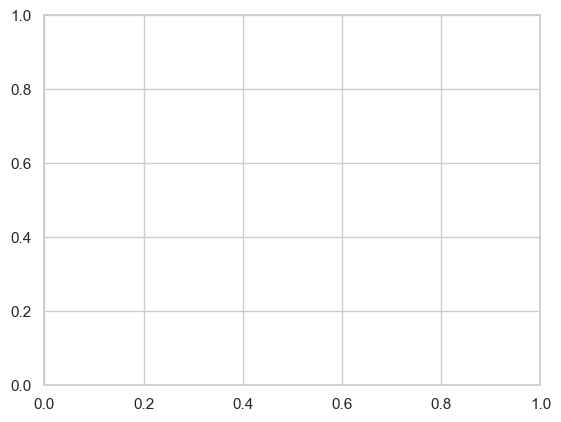

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a professional theme
sns.set_theme(style="whitegrid")
# Prevent scientific notation in charts
plt.ticklabel_format(style='plain', axis='y')

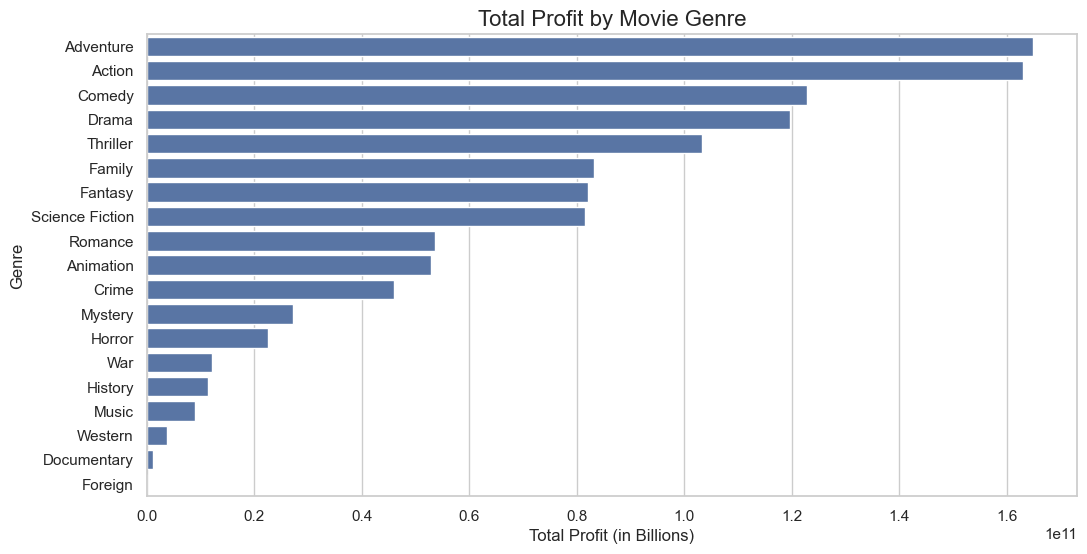

In [35]:
df_genres = pd.read_sql_query(query_3, conn)

# 2. Create the plot
plt.figure(figsize=(12, 6))
plot = sns.barplot(data=df_genres, x='total_revenue', y='genre_name')

plt.title('Total Profit by Movie Genre', fontsize=16)
plt.xlabel('Total Profit (in Billions)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()